# Robot Data Streaming, Database Persistence, Analysis & Predictive Analytics

This project demonstrates an end-to-end workflow for collecting, streaming, storing, analyzing, and monitoring robot operational data.

The system combines real-time data streaming, PostgreSQL database persistence, exploratory data analysis, anomaly detection, and predictive analytics to provide insights into robot operating conditions and support maintenance decision-making.

# Manufacturing Robot Data Streaming, Analysis & Predictive Analytics

## Group Members and Responsibilities

This project was completed collaboratively by a team of four. Each team member was responsible for a specific component of the system, while the components were integrated to form the complete workflow.

| Group Member | Role | Responsibilities |
|---|---|---|
| **Sultan Atanda (9114837)** | Neon Database & Data Persistence | Designed and implemented the Neon PostgreSQL database, created and maintained the `robot_data` table, developed the database service functions for connecting, creating tables, inserting records, and retrieving data, and integrated the database with the robot data pipeline. |
| **Eche Oji (9078881)** | Data Streaming & Collection | Responsible for the robot data streaming component, including the streaming simulator and the process of generating and passing robot measurements through the system. |
| **John Buni (9115726)** | Dashboard & Visualization | Responsible for developing the robot monitoring dashboard and presenting streamed robot data through visual displays. |
| **Antonio Sainz (9072844)** | Analysis & Predictive Analytics | Responsible for analyzing the historical robot data, identifying anomalies, evaluating robot operating conditions, and developing the predictive maintenance analysis. |

### Team Workflow

The different components work together as an integrated pipeline:

**Robot Data → Data Streaming → Database Persistence → Data Analysis → Anomaly Detection → Predictive Analytics → Monitoring Dashboard**


## Project Overview

The project focuses on developing a data pipeline for robot operational data. The workflow begins with robot measurements being generated through a simulated streaming process. The incoming data can then be stored in a PostgreSQL database hosted on Neon for persistent storage and later analysis.

The stored data provides the foundation for exploratory analysis, anomaly detection, and predictive analytics. A monitoring dashboard can also use the data to provide a visual representation of robot operation.

The overall objective is to demonstrate how streaming robot data can be transformed into structured information that supports monitoring and maintenance-related decision-making.

# 1. Project Setup

Before working with the robot data, the required Python libraries and project modules are imported.

These libraries provide the functionality required for data manipulation, visualization, database communication, and the other components used throughout the project.

#### Library Import

In [ ]:
import os
import time
from IPython.display import display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


#### Project Module imports

In [ ]:
from src.streaming_simulator import StreamingSimulator
from src.database_service import get_records
from src.database_service import connect_db
from src.database_service import create_table
from src.database_service import insert_record
from src.streaming_simulator import StreamingSimulator
from src.dashboard import RobotDashboard

## Database setup and Testing

The project uses Neon PostgreSQL to persist robot measurements.
Before streaming data into the system, we first establish a database
connection and create the required table structure.


### Establishing the Database Connection

The first step is to establish a connection between the Python environment and the Neon PostgreSQL database.

A dedicated database connection function is used so that the connection process can be reused by different parts of the project.

In [ ]:
db = connect_db()
db.close()

### Creating the Robot Data Table

The `robot_data` table provides the database structure used to store robot measurements.

The table contains the relevant robot characteristics, axis measurements, and timestamp information required by the project.

In [ ]:
create_table()

### Testing Database Operations

After creating the table, basic database operations are tested to confirm that records can be inserted into the database and retrieved successfully.

This provides an initial validation that the database layer is working before it is connected to the larger data pipeline.

In [ ]:
insert_record(
    "current",
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    "2022-10-17T12:18:29.222Z"
)

## Data Streaming

The next stage of the project is the robot data streaming component.

The `StreamingSimulator` is used to simulate the arrival of robot measurements over time. Rather than loading the entire dataset into memory and processing it as a single batch, the simulator provides individual data points that represent incoming robot measurements.

This allows the project to demonstrate how a real-time robot monitoring system could receive and process data continuously.

## Streaming Simulator

The streaming simulator reads the available robot measurements and provides individual records when requested.

Each returned record represents a new robot measurement that can subsequently be stored, analyzed, or displayed by the system.

In [ ]:
ss = StreamingSimulator("data/robot_data.csv")
ss.data.head()

In [ ]:
for i in range(5):

    data_point = ss.nextDataPoint()

    if data_point is None:
        break

    display(data_point.to_frame().T)

    time.sleep(2)

### Streaming Demonstration

The following demonstration shows how individual robot measurements can be retrieved from the streaming simulator.

The purpose of this step is to verify that the streaming component is producing records correctly before integrating it with the database and monitoring components.

In [ ]:
ss.data = ss.data.head(5)
ss.current_index = 0

ss.start_stream()

In [ ]:
records = get_records()

print(records)

### Preparing the Database for Analysis

Before beginning the analysis, the existing records in the `robot_data` table are cleared.

The table structure is preserved, but previously inserted records are removed. This ensures that the analysis starts with a clean database state and avoids including records generated during earlier database and streaming demonstrations.

In [ ]:
connection = connect_db()

with connection.cursor() as cursor:
    cursor.execute("TRUNCATE TABLE robot_data")

connection.commit()
connection.close()

print("robot_data table cleared successfully.")

## Live Dashboard Service

In [ ]:
ss = StreamingSimulator("data/robot_data.csv")
dashboard = RobotDashboard()

ss.start_stream(dashboard)

## Final Robot Behavior Across the Full Dataset

The chart below visualizes the robot's activity across the complete dataset. It shows the readings from Axes 1 to 8 over time and provides an overall view of the robot's behavior throughout the recorded period.

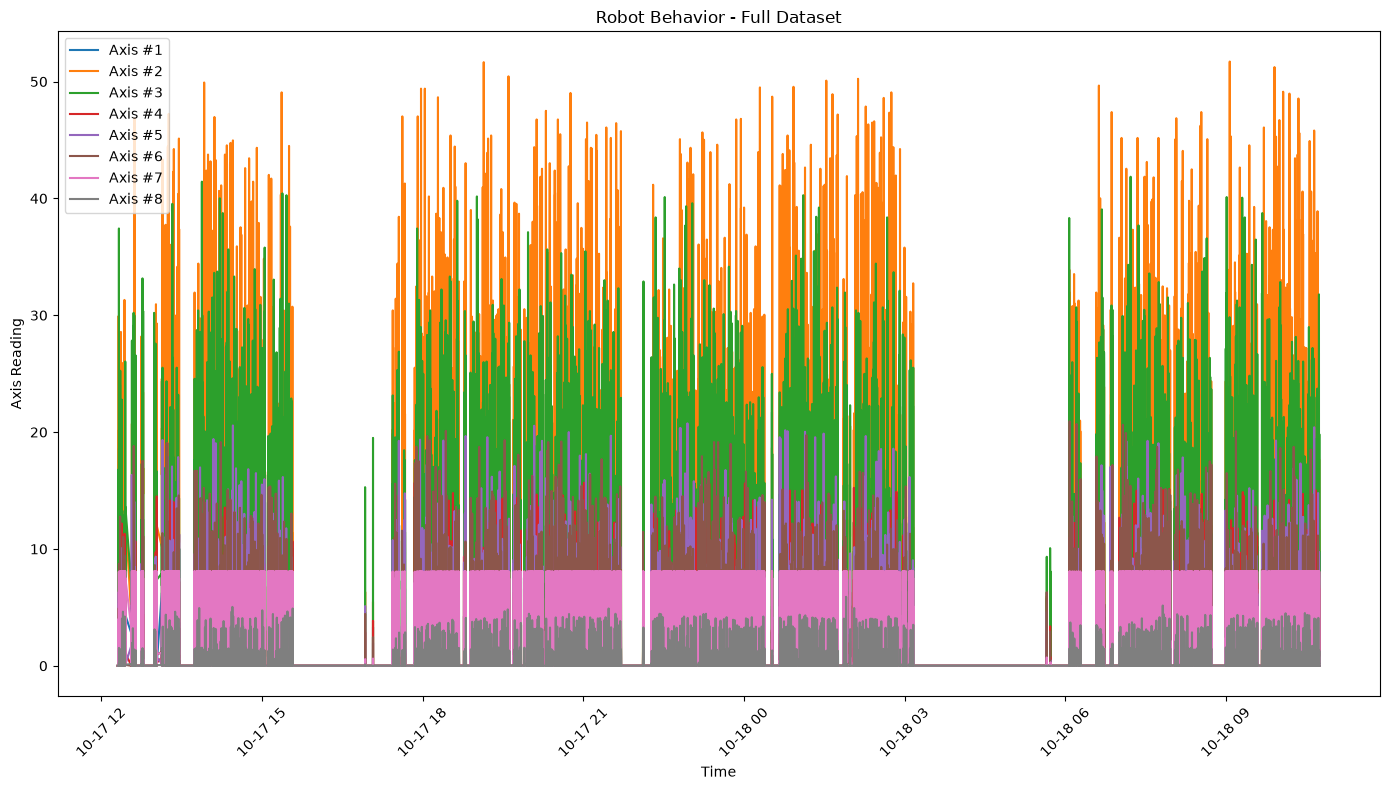

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/robot_data.csv")

df["Time"] = pd.to_datetime(df["Time"])

plt.figure(figsize=(14, 8))

for axis in range(1, 9):
    plt.plot(
        df["Time"],
        df[f"Axis #{axis}"],
        label=f"Axis #{axis}"
    )

plt.xlabel("Time")
plt.ylabel("Axis Reading")
plt.title("Robot Behavior - Full Dataset")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Analysis, Anomalies & Predictive Analytics

Analysis of the robot data: patterns, robot state, anomalies, maintenance alerts and a simple predictive component. The CSV is the data source, so nothing is loaded into the database here.

**Robot state.** The robot is `RUNNING` when its axes draw current and `STOPPED` otherwise.

## 1. Patterns and Robot State

Axes with data: ['Axis #1', 'Axis #2', 'Axis #3', 'Axis #4', 'Axis #5', 'Axis #6', 'Axis #7', 'Axis #8']

Robot state (% of readings):
State
STOPPED    64.6
RUNNING    35.4

Axis statistics while RUNNING:
          mean   std    max
Axis #1   2.05  3.24  23.61
Axis #2  10.21  8.15  51.71
Axis #3   7.65  6.00  41.86
Axis #4   1.75  2.24  15.67
Axis #5   2.70  2.79  20.75
Axis #6   1.69  2.73  20.93
Axis #7   2.46  3.06   8.11
Axis #8   0.29  0.67   5.91


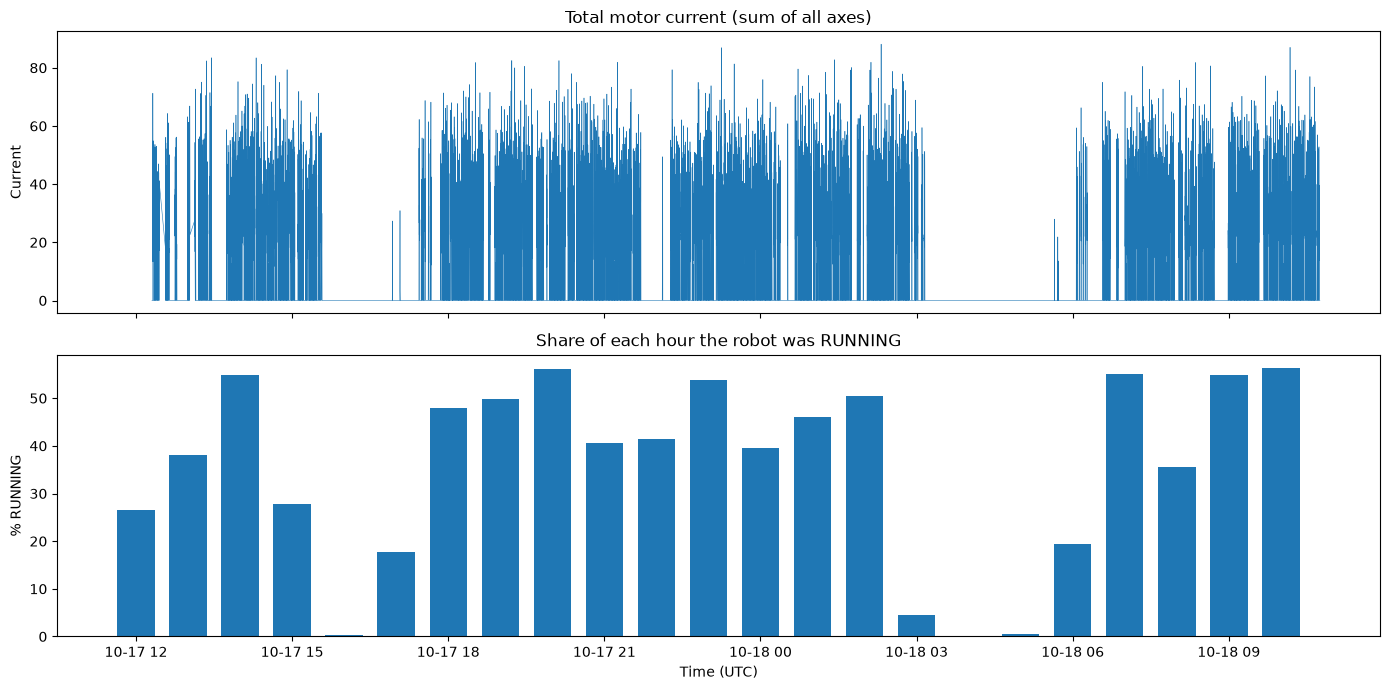

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/robot_data.csv")
df["Time"] = pd.to_datetime(df["Time"])

axes = [c for c in df.columns if c.startswith("Axis") and df[c].notna().any()]
df["Total"] = df[axes].sum(axis=1)

# Robot state: RUNNING when the axes draw current, otherwise STOPPED
df["State"] = np.where(df["Total"] > 0.5, "RUNNING", "STOPPED")

print("Axes with data:", axes)
print("\nRobot state (% of readings):")
print(df["State"].value_counts(normalize=True).mul(100).round(1).to_string())
print("\nAxis statistics while RUNNING:")
print(df.loc[df["State"] == "RUNNING", axes].describe().T[["mean", "std", "max"]].round(2))

hourly_running = df.set_index("Time")["State"].eq("RUNNING").resample("1h").mean() * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
ax1.plot(df["Time"], df["Total"], linewidth=0.4)
ax1.set_title("Total motor current (sum of all axes)")
ax1.set_ylabel("Current")
ax2.bar(hourly_running.index, hourly_running.values, width=0.03)
ax2.set_title("Share of each hour the robot was RUNNING")
ax2.set_ylabel("% RUNNING")
ax2.set_xlabel("Time (UTC)")
fig.tight_layout()
plt.show()

## 2. Anomalies and Maintenance Alerts

The first 40% of the data is the **baseline**. For each axis, the limit is the highest value seen while running in the baseline. A reading above its limit is an anomaly. This is used instead of a global mean + 3 standard deviations because most readings are zero, which makes that rule flag normal working values.

Alerts: one axis above its limit = `WARNING`, two or more = `MAINTENANCE`.

In [ ]:
split = int(len(df) * 0.4)
baseline = df.iloc[:split]
limits = baseline.loc[baseline["State"] == "RUNNING", axes].max()

flags = df[axes].gt(limits)
flags[df["State"] == "STOPPED"] = False
df["Abnormal_Axes"] = flags.sum(axis=1)

df["Alert"] = np.select(
    [df["Abnormal_Axes"] >= 2, df["Abnormal_Axes"] == 1],
    ["MAINTENANCE", "WARNING"],
    default="NORMAL",
)
df["Notification"] = df["Alert"].map({
    "NORMAL": "No maintenance alert",
    "WARNING": "Monitor abnormal axis",
    "MAINTENANCE": "Maintenance inspection recommended",
})

after_baseline = df.iloc[split:]
print("Axis limits (highest value in the baseline):")
print(limits.round(2).to_string())
print(f"\nAnomalous readings: {int((df['Abnormal_Axes'].iloc[:split] > 0).sum())} in the baseline, "
      f"{int((after_baseline['Abnormal_Axes'] > 0).sum())} in the rest of the data")

naive = df[axes].gt(df[axes].mean() + 3 * df[axes].std()).any(axis=1).sum()
print(f"For comparison, a global mean + 3 std rule would flag {naive:,} readings")

print("\nAlerts:")
print(df["Alert"].value_counts().to_string())

alerts = df[df["Alert"] != "NORMAL"]
alert_axis = flags.loc[alerts.index].idxmax(axis=1)
print("\nAlert readings:")
print(alerts.assign(Axis=alert_axis)[["Time", "Axis", "Alert", "Notification"]].to_string(index=False))

# Do anomalies affect operation? Comparing the next 30 readings after an anomaly with the next 30 after any other RUNNING reading.

after_mean = df["Total"].rolling(30).mean().shift(-30)
after_stopped = df["State"].eq("STOPPED").rolling(30).mean().shift(-30) * 100
is_anomaly = df["Abnormal_Axes"] > 0
comparable = after_mean.notna() & (df["State"] == "RUNNING") & ~is_anomaly
n_anomalies = int((is_anomaly & after_mean.notna()).sum())

print(f"\nEffect on operation ({n_anomalies} anomalies):")
if n_anomalies < 5:
    print("Too few anomalies to draw a conclusion.")
else:
    print(f"Average current in the next 30 readings: {after_mean[is_anomaly].mean():.1f} after an anomaly "
          f"vs {after_mean[comparable].mean():.1f} otherwise")
    print(f"% of the next 30 readings STOPPED: {after_stopped[is_anomaly].mean():.1f} after an anomaly "
          f"vs {after_stopped[comparable].mean():.1f} otherwise")
    if n_anomalies < 30:
        print("Small sample: we will treat this comparison as indicative only.")

Axis limits (highest value in the baseline):
Axis #1    23.61
Axis #2    51.66
Axis #3    41.43
Axis #4    15.67
Axis #5    20.57
Axis #6    20.11
Axis #7     8.11
Axis #8     5.04

Anomalous readings: 0 in the baseline, 8 in the rest of the data
For comparison, a global mean + 3 std rule would flag 7,365 readings

Alerts:
Alert
NORMAL     39664
WARNING        8

Alert readings:
                            Time    Axis   Alert          Notification
2022-10-17 22:56:32.800000+00:00 Axis #5 WARNING Monitor abnormal axis
2022-10-18 01:54:17.237000+00:00 Axis #8 WARNING Monitor abnormal axis
2022-10-18 06:04:38.664000+00:00 Axis #6 WARNING Monitor abnormal axis
2022-10-18 06:12:22.487000+00:00 Axis #6 WARNING Monitor abnormal axis
2022-10-18 07:04:15.633000+00:00 Axis #6 WARNING Monitor abnormal axis
2022-10-18 07:12:57.662000+00:00 Axis #3 WARNING Monitor abnormal axis
2022-10-18 07:48:57.745000+00:00 Axis #8 WARNING Monitor abnormal axis
2022-10-18 09:04:00.191000+00:00 Axis #2 WARNING M

## 3. Predictive Analytics

Without failure records the module tracks a health indicator instead: the average current while the robot is running, per hour. It fits a trend line, forecasts the next hour, and recommends a maintenance check if the forecast is more than 10% above the early baseline level. The same function can be called on new streamed data.

Baseline level: 28.9
Trend: +0.008 per hour
Forecast for the next hour: 28.9 (+0.2% vs baseline)
Status: NO ACTION NEEDED


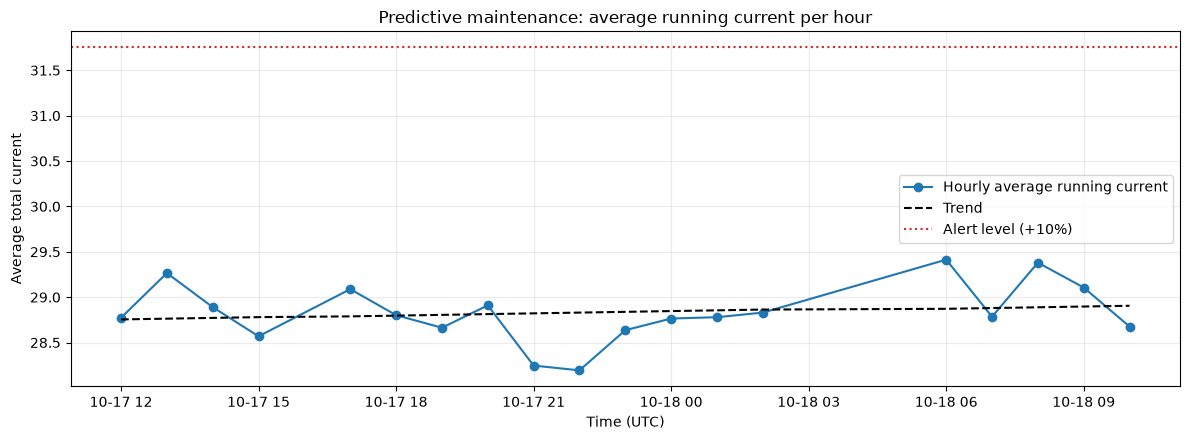

In [3]:
def predictive_analytics(data, min_readings=100, alert_increase_pct=10):
    """Trend of hourly average running current, forecast for the next hour and a maintenance status."""
    running = data[data["State"] == "RUNNING"].set_index("Time")["Total"]
    hourly = running.resample("1h").agg(["mean", "size"])
    hourly = hourly[hourly["size"] >= min_readings]["mean"]

    hours = np.arange(len(hourly))
    slope, intercept = np.polyfit(hours, hourly.values, 1)
    forecast = slope * len(hourly) + intercept

    baseline_level = hourly.iloc[: max(3, int(len(hourly) * 0.4))].mean()
    change_pct = (forecast - baseline_level) / baseline_level * 100
    status = "MAINTENANCE CHECK RECOMMENDED" if change_pct > alert_increase_pct else "NO ACTION NEEDED"

    return {"hourly": hourly, "slope": slope, "intercept": intercept, "forecast": forecast,
            "baseline_level": baseline_level, "change_pct": change_pct, "status": status}


result = predictive_analytics(df)
hourly = result["hourly"]

print(f"Baseline level: {result['baseline_level']:.1f}")
print(f"Trend: {result['slope']:+.3f} per hour")
print(f"Forecast for the next hour: {result['forecast']:.1f} ({result['change_pct']:+.1f}% vs baseline)")
print("Status:", result["status"])

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(hourly.index, hourly.values, marker="o", label="Hourly average running current")
ax.plot(hourly.index, result["slope"] * np.arange(len(hourly)) + result["intercept"],
        linestyle="--", color="black", label="Trend")
ax.axhline(result["baseline_level"] * 1.10, color="tab:red", linestyle=":", label="Alert level (+10%)")
ax.set_title("Predictive maintenance: average running current per hour")
ax.set_xlabel("Time (UTC)")
ax.set_ylabel("Average total current")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## 4. Findings

In [4]:
running_pct = (df["State"] == "RUNNING").mean() * 100

print("PATTERNS AND ROBOT STATE")
print(f"  The robot is running {running_pct:.0f}% of the time and stopped {100 - running_pct:.0f}%.")

print("\nANOMALIES AND ALERTS")
print(f"  {int((after_baseline['Abnormal_Axes'] > 0).sum())} anomalous readings after the baseline "
      f"({int((df['Abnormal_Axes'] > 0).iloc[:split].sum())} in the baseline).")
print(f"  Alerts: {int((df['Alert'] == 'WARNING').sum())} WARNING, {int((df['Alert'] == 'MAINTENANCE').sum())} MAINTENANCE.")

print("\nEFFECT ON OPERATION")
print(f"  Based on only {n_anomalies} anomalies, so no reliable effect on operation can be concluded.")

print("\nPREDICTIVE ANALYTICS")
print(f"  Hourly running current trend {result['slope']:+.3f} per hour; "
      f"next-hour forecast {result['change_pct']:+.1f}% vs baseline -> {result['status']}.")

PATTERNS AND ROBOT STATE
  The robot is running 35% of the time and stopped 65%.

ANOMALIES AND ALERTS
  8 anomalous readings after the baseline (0 in the baseline).
  Alerts: 8 WARNING, 0 MAINTENANCE.

EFFECT ON OPERATION
  Based on only 8 anomalies, so no reliable effect on operation can be concluded.

PREDICTIVE ANALYTICS
  Hourly running current trend +0.008 per hour; next-hour forecast +0.2% vs baseline -> NO ACTION NEEDED.


### Business significance

- **Pattern analysis:** the robot alternates between working periods and stops, so any monitoring has to look at running data separately from stopped data.
- **Anomalies:** an anomaly means a reading higher than anything seen in the baseline. It is a reason to look closer, not proof of a fault, and it depends on the baseline being healthy operation.
- **Maintenance alerts:** WARNING (one axis) and MAINTENANCE (two or more axes) can be raised as notifications for the maintenance team as readings stream in.
- **Predictive analytics:** the trend check gives an early warning of gradually increasing load. With about one day of data it cannot show long-term wear, and real failure prediction would need maintenance and failure records.
- **Value:** catching unusual axis behavior early lets maintenance be planned instead of reacting to unexpected stops.